In [1]:
import sys
import os

print("Current Working Directory:", os.getcwd())

Current Working Directory: /Users/anjansuputra/Documents/GitHub/Emasters_Group-2_CapstoneProject


In [2]:
from pathlib import Path
import json
import re
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

project_root = Path.cwd()
sys.path.append(str(project_root))
sys.path.append(str(project_root / "src"))

from config import load_config
from src.data.data_loader import DatasetLoader
from src.models.load_model import ModelLoader
from src.generators.program_generator import GenerationPipeline
from src.generators.text_to_mongo_generator import TextToMongoGenerator
from src.evaluation.metrics import EvaluationMetrics
from src.evaluation.visualization import ResultVisualizer

print("✅ Imports ready.")

✅ Imports ready.


In [3]:
config = load_config("configs/config.yaml")

bertscore_model_resolved = config.evaluation.resolve_bertscore_model(base_dir="models/codebert-base")

print(f"Base Model      : {config.model_name}")
print(f"Device          : {config.evaluation.device}")
print(f"LoRA Output Dir : {config.lora.output_dir}")
if bertscore_model_resolved == config.evaluation.bertscore_model:
    print(f"BERTScore Model : {bertscore_model_resolved}  (⚠️ local checkpoint not found at "
          f"'{config.evaluation.bertscore_local_path}' -- will download from Hugging Face Hub)")
else:
    print(f"BERTScore Model : {bertscore_model_resolved}  (✅ loaded from local checkpoint)")

Base Model      : Qwen/Qwen2.5-Coder-0.5B-Instruct
Device          : cpu
LoRA Output Dir : models/checkpoints/lora_finetuned
BERTScore Model : /Users/anjansuputra/Documents/GitHub/Emasters_Group-2_CapstoneProject/models/codebert-base  (✅ loaded from local checkpoint)


In [4]:
N_EVAL_SAMPLES = 100

data_loader = DatasetLoader(target_filename="qwen_spider_mongodb_conversion.json")
mongo_data = data_loader.load_data()
eval_samples = mongo_data[:N_EVAL_SAMPLES]

print(f"Loaded {len(mongo_data)} Text-to-MongoDB records from qwen_spider_mongodb_conversion.json")
print(f"Using {len(eval_samples)} samples for this evaluation run.")

2026-08-27 13:36:32,406 - src.data.data_loader - INFO - ✅ Found qwen_spider_mongodb_conversion.json at: /Users/anjansuputra/Documents/GitHub/Emasters_Group-2_CapstoneProject/qwen_spider_mongodb_conversion.json
2026-08-27 13:36:32,407 - src.data.data_loader - INFO - 📂 Loading data from /Users/anjansuputra/Documents/GitHub/Emasters_Group-2_CapstoneProject/qwen_spider_mongodb_conversion.json...
2026-08-27 13:36:32,414 - src.data.data_loader - INFO - ✅ Successfully loaded 1114 records.


Loaded 1114 Text-to-MongoDB records from qwen_spider_mongodb_conversion.json
Using 100 samples for this evaluation run.


In [5]:
model_loader = ModelLoader(config)
tokenizer = model_loader.load_tokenizer()
base_model = model_loader.load_base_model()

lora_path = Path(config.lora.output_dir)

if lora_path.exists() and (lora_path / "adapter_config.json").exists():
    print(f"✅ Found existing LoRA adapter at {lora_path}")
    lora_model = model_loader.autodetect_saved_model(str(lora_path))
else:
    print("🔄 No usable LoRA adapter found — training a new one on the Text-to-MongoDB data...")

    training_data = data_loader.get_training_data()
    print(f"Prepared {len(training_data)} training examples for LoRA fine-tuning.")

    lora_model = model_loader.setup_lora(
        trainable_fraction=config.lora.trainable_fraction,
        r=config.lora.r,
        alpha=config.lora.alpha,
        dropout=config.lora.dropout,
    )

    lora_model = model_loader.train_lora(
        train_data=training_data,
        output_dir=str(lora_path),
        epochs=config.lora.epochs,
        batch_size=config.lora.batch_size,
        grad_accum=4,
        lr=config.lora.learning_rate,
        max_length=config.generation.max_length,
    )

    print(f"✅ LoRA adapter saved to {lora_path}")

finetuned_pipeline = GenerationPipeline(lora_model, tokenizer, config.generation)
print("✅ Fine-tuned (LoRA) model loaded and ready for generation.")

2026-08-27 13:36:32,464 - src.models.load_model - INFO - 🖥️ Initialized ModelLoader | Device: mps | Dtype: torch.float16
2026-08-27 13:36:32,466 - src.models.load_model - INFO - 🔄 Loading tokenizer: Qwen/Qwen2.5-Coder-0.5B-Instruct
2026-08-27 13:36:33,112 - src.models.load_model - INFO - 🔄 Loading base model: Qwen/Qwen2.5-Coder-0.5B-Instruct
2026-08-27 13:36:38,672 - src.models.load_model - INFO - ✅ Found saved LoRA adapter at models/checkpoints/lora_finetuned. Loading...


✅ Found existing LoRA adapter at models/checkpoints/lora_finetuned
✅ Fine-tuned (LoRA) model loaded and ready for generation.


## Task — Text-to-MongoDB Query Generation (Fine-Tuned Model)

In [6]:
text_to_mongo_gen = TextToMongoGenerator(finetuned_pipeline, config)

print(f"Generating MongoDB queries for {len(eval_samples)} samples using the Fine-Tuned Model...")

finetuned_batch_results = text_to_mongo_gen.generate_batch(
    eval_samples,
    output_path="outputs/generated/finetuned_mongo_predictions.json"
)

questions     = [r["question"] for r in finetuned_batch_results]
gold_queries  = [r["gold_query"] for r in finetuned_batch_results]
pred_queries  = [r["generated_query"] for r in finetuned_batch_results]
latencies_ms  = [r["latency_ms"] for r in finetuned_batch_results]

mongo_results_df = pd.DataFrame({
    "question": questions,
    "gold_query": gold_queries,
    "predicted_query": pred_queries,
    "latency_ms": latencies_ms,
})
mongo_results_df.head(10)

2026-08-27 13:36:39,591 - src.generators.text_to_mongo_generator - INFO - 🚀 Starting batch MongoDB query generation for 100 examples...


Generating MongoDB queries for 100 samples using the Fine-Tuned Model...


Generating MongoDB Queries:   0%|          | 0/100 [00:00<?, ?query/s]/Users/anjansuputra/anaconda3/envs/ApexEnv/lib/python3.10/site-packages/transformers/generation/utils.py:1562: UserWarning: The operator 'aten::isin.Tensor_Tensor_out' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:13.)
  and torch.isin(elements=eos_token_tensor, test_elements=pad_token_tensor).any()
Generating MongoDB Queries: 100%|██████████| 100/100 [1:11:18<00:00, 42.79s/query]
2026-08-27 14:47:58,428 - src.generators.text_to_mongo_generator - INFO - ✅ Successfully saved 100 generated queries to outputs/generated/finetuned_mongo_predictions.json


,question,gold_query,predicted_query,latency_ms
0,How many singers do we have?,db.singer.countDocuments(),db.sings.countDocuments()#db.singer.aggregate(...,58030.97
1,What is the total number of singers?,db.singer.countDocuments(),db.singer.countDocuments()#db.singer.aggregate...,39588.42
2,"Show name, country, age for all singers ordere...","db.singer.find({}, {Name: 1, Country: 1, Age: ...","db.singer.find({}, {Name: 1, Country: 2, _id: ...",41683.07
3,"What are the names, countries, and ages for ev...","db.singer.find({}, {Name: 1, Country: 1, Age: ...",db.singers.find().sort({Age: -1})#db.singer.ag...,40376.86
4,"What is the average, minimum, and maximum age ...","db.singer.aggregate([{$match: {Country: ""Franc...","db.ages.aggregate([{$match: {CountryCode: ""FR""...",40953.38
5,"What is the average, minimum, and maximum age ...","db.singer.aggregate([{$match: {Country: ""Franc...","db.affaire.aggregate([{$match:{Genre:""FRENCH""}...",41205.89
6,Show the name and the release year of the song...,"db.singer.aggregate([{$sort: {Age: 1}}, {$limi...",db.ongs.find().sort({Singer_ID: 1}).limit(1).p...,40672.91
7,What are the names and release years for all t...,"db.singer.aggregate([{$sort: {Age: 1}}, {$limi...","db.ongs.find({Singer_ID: 1, _id: 0}).sort({Age...",42132.87
8,What are all distinct countries where singers ...,"db.singer.distinct(""Country"", {Age: {$gt: 20}})","db.actors.aggregate([{$match:{Age:>20}}, {$gro...",45457.55
9,What are the different countries with singers ...,"db.singer.distinct(""Country"", {Age: {$gt: 20}})","db.singer.aggregate([{$match:{Age:>20}}, {$gro...",13290.73


### Text-to-MongoDB Metrics (Fine-Tuned Model)

In [12]:
bleu_score = EvaluationMetrics.compute_bleu(gold_queries, pred_queries)
rouge_scores = EvaluationMetrics.compute_rouge(gold_queries, pred_queries)

codebert_score = EvaluationMetrics.compute_bertscore(
    gold_queries, pred_queries, device=config.evaluation.device, model_type=bertscore_model_resolved
)

response_accuracy = round(
    sum(EvaluationMetrics.compute_response_accuracy(g, p) for g, p in zip(gold_queries, pred_queries)) / len(gold_queries),
    4
) if gold_queries else 0.0

mongo_metrics_finetuned = {
    "BLEU": round(bleu_score, 4),
    "CodeBERTScore": round(codebert_score, 4),
    "ROUGE-1": round(rouge_scores["ROUGE-1"], 4),
    "ROUGE-L": round(rouge_scores["ROUGE-L"], 4),
    "Response_Accuracy": response_accuracy,
}

avg_latency_ms = round(sum(latencies_ms) / len(latencies_ms), 2) if latencies_ms else 0.0

print(f"\n✅ Text-to-MongoDB Metrics — Fine-Tuned Model:")
for k, v in mongo_metrics_finetuned.items():
    print(f"   {k:20s}: {v}")
print(f"   {'Avg_Latency_ms':20s}: {avg_latency_ms}")

2026-08-27 14:50:30,869 - absl - INFO - Using default tokenizer.
/Users/anjansuputra/anaconda3/envs/ApexEnv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



✅ Text-to-MongoDB Metrics — Fine-Tuned Model:
   BLEU                : 0.2184
   CodeBERTScore       : 0.8917
   ROUGE-1             : 0.5459
   ROUGE-L             : 0.478
   Response_Accuracy   : 0.7382
   Avg_Latency_ms      : 42785.66


### Text-to-MongoDB Visualization (Fine-Tuned Model)

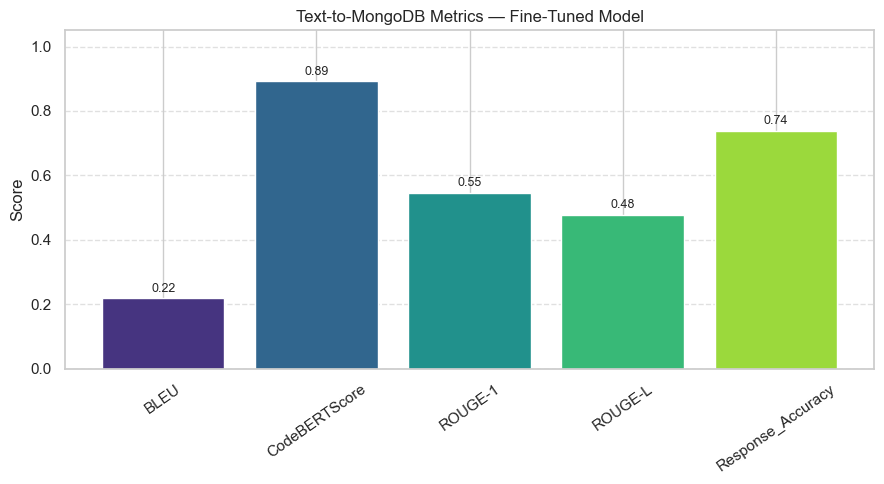

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

metric_names = list(mongo_metrics_finetuned.keys())
metric_values = list(mongo_metrics_finetuned.values())
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(metric_names)))

ax.bar(metric_names, metric_values, color=colors)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Text-to-MongoDB Metrics — Fine-Tuned Model")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", linestyle="--", alpha=0.6)

for i, v in enumerate(metric_values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
Path("src/plots").mkdir(parents=True, exist_ok=True)
plt.savefig("src/plots/text_to_mongo_finetuned_metrics.png", bbox_inches="tight")
plt.show()

# --- Qualitative sample viewer ---
sample_view = mongo_results_df.copy()

## Consolidated Fine-Tuned Model Results Summary

In [14]:
combined_results_finetuned = {
    "Text_to_MongoDB": mongo_metrics_finetuned,
}

visualizer = ResultVisualizer(output_dir=config.outputs.plots_dir if hasattr(config, "outputs") else "src/plots")
visualizer.plot_comparison(
    combined_results_finetuned,
    save_name="finetuned_text_to_mongo.png",
    bertscore_model_label=bertscore_model_resolved,
)

summary_rows = []
for task, metrics in combined_results_finetuned.items():
    for metric, value in metrics.items():
        summary_rows.append({"Task": task, "Metric": metric, "Score": value})
summary_rows.append({"Task": "Text_to_MongoDB", "Metric": "Avg_Latency_ms", "Score": avg_latency_ms})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

output_path = Path("output/generated") / "finetuned_model_results.json"
output_path.parent.mkdir(parents=True, exist_ok=True)
with open(output_path, "w", encoding="utf-8") as f:
    json.dump({**combined_results_finetuned, "Avg_Latency_ms": avg_latency_ms, "n_samples": len(eval_samples)}, f, indent=2)

print(f"\n✅ Fine-Tuned Model results saved to: {output_path}")

2026-08-27 14:51:09,306 - src.evaluation.visualization - INFO - ✅ Saved comparison plot to output/plots/finetuned_text_to_mongo.png


,Task,Metric,Score
0,Text_to_MongoDB,BLEU,0.2184
1,Text_to_MongoDB,CodeBERTScore,0.8917
2,Text_to_MongoDB,ROUGE-1,0.5459
3,Text_to_MongoDB,ROUGE-L,0.4780
4,Text_to_MongoDB,Response_Accuracy,0.7382
5,Text_to_MongoDB,Avg_Latency_ms,42785.6600



✅ Fine-Tuned Model results saved to: output/generated/finetuned_model_results.json


## Baseline vs. Fine-Tuned Comparison

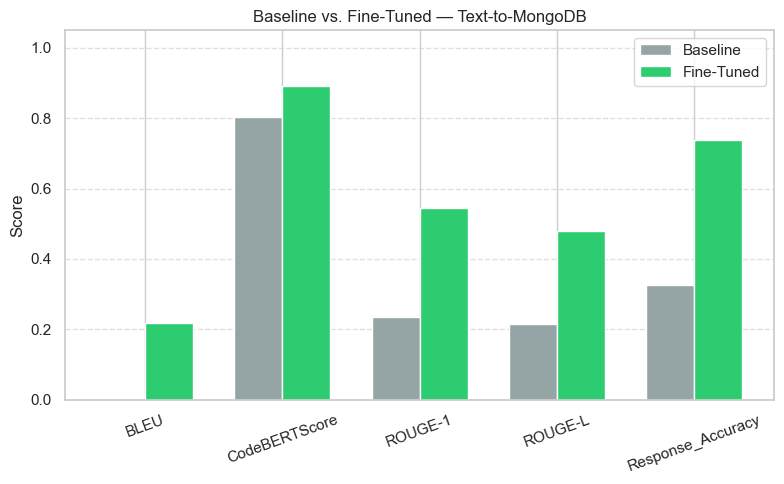

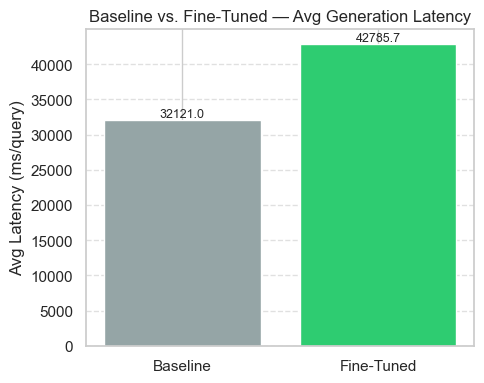

In [15]:
baseline_results_path = Path("output/generated/baseline_model_results.json")

if baseline_results_path.exists():
    with open(baseline_results_path, "r", encoding="utf-8") as f:
        baseline_results = json.load(f)

    base_metrics = baseline_results.get("Text_to_MongoDB", {})
    fine_metrics = combined_results_finetuned.get("Text_to_MongoDB", {})
    common_metrics = [m for m in fine_metrics if m in base_metrics]

    if common_metrics:
        x = np.arange(len(common_metrics))
        width = 0.35

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(x - width / 2, [base_metrics[m] for m in common_metrics], width, label="Baseline", color="#95a5a6")
        ax.bar(x + width / 2, [fine_metrics[m] for m in common_metrics], width, label="Fine-Tuned", color="#2ecc71")
        ax.set_xticks(x)
        ax.set_xticklabels(common_metrics, rotation=20)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Score")
        ax.set_title("Baseline vs. Fine-Tuned — Text-to-MongoDB")
        ax.legend()
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.savefig("src/plots/baseline_vs_finetuned_text_to_mongo.png", bbox_inches="tight")
        plt.show()

    base_latency = baseline_results.get("Avg_Latency_ms")
    fine_latency = avg_latency_ms
    if base_latency is not None:
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.bar(["Baseline", "Fine-Tuned"], [base_latency, fine_latency], color=["#95a5a6", "#2ecc71"])
        ax.set_ylabel("Avg Latency (ms/query)")
        ax.set_title("Baseline vs. Fine-Tuned — Avg Generation Latency")
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        for i, v in enumerate([base_latency, fine_latency]):
            ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
        plt.tight_layout()
        plt.savefig("src/plots/baseline_vs_finetuned_latency.png", bbox_inches="tight")
        plt.show()
else:
    print("Run baseline_model.ipynb first to enable the Baseline vs. Fine-Tuned comparison.")